In [146]:
import pandas as pd
import numpy as np
import yfinance as yfin
import ta

In [147]:
df = yfin.download("BTC-USD", start="2020-01-01", end="2026-01-01")
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095
...,...,...,...,...,...
2025-12-27,87802.156250,87874.781250,87182.976562,87301.429688,13741199310
2025-12-28,87835.835938,87986.890625,87394.953125,87799.343750,15156557929


In [148]:
df.columns = df.columns.droplevel(1)

In [149]:
# EMAs
df['EMA_5'] = ta.trend.ema_indicator(close=df['Close'], window=5, fillna=True) / df['Close']
df['EMA_20'] = ta.trend.ema_indicator(close=df['Close'], window=20, fillna=True) / df['Close']
df['EMA_50'] = ta.trend.ema_indicator(close=df['Close'], window=50, fillna=True) / df['Close']
df['EMA_100'] = ta.trend.ema_indicator(close=df['Close'], window=100, fillna=True) / df['Close']

# índice de fuerza relativa
df['RSI'] = ta.momentum.rsi(close=df['Close'], fillna=True)

# rango verdadero medio
df['ATR'] = ta.volatility.average_true_range(
    high=df['High'],
    low=df['Low'],
    close=df['Close'],
    fillna=True
)

# rango de porcentaje de Williams
df['Williams'] = ta.momentum.williams_r(
    high=df['High'],
    low=df['Low'],
    close=df['Close'],
    fillna=True
)
df

Price,Close,High,Low,Open,Volume,EMA_5,EMA_20,EMA_50,EMA_100,RSI,ATR,Williams
Date,,,,,,,,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997,1.000000,1.000000,1.000000,1.000000,100.000000,0.000000,-68.218694
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465,1.020491,1.027809,1.029530,1.030127,0.000000,0.000000,-84.266248
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032,0.980369,0.979655,0.979969,0.980121,64.320963,0.000000,-13.801564
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275,0.981112,0.973726,0.972398,0.971988,68.334871,0.000000,-3.264899
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095,0.987350,0.976150,0.973397,0.972457,68.373359,0.000000,-21.156391
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,87802.156250,87874.781250,87182.976562,87301.429688,13741199310,0.997804,1.008144,1.053045,1.117371,44.616331,2800.162979,-44.509460
2025-12-28,87835.835938,87986.890625,87394.953125,87799.343750,15156557929,0.998281,1.007019,1.050577,1.114627,44.754060,2642.432587,-43.954204
2025-12-29,87138.140625,90299.156250,86717.914062,87835.789062,48411625849,1.004183,1.013646,1.056676,1.121105,42.401671,2709.490416,-55.456666


In [150]:
cl = np.array(df['Close'])
target = np.where(cl[1:] > cl[:-1], 1, -1)

df.drop(df.tail(1).index, inplace=True)


df['Target'] = target
df


Price,Close,High,Low,Open,Volume,EMA_5,EMA_20,EMA_50,EMA_100,RSI,ATR,Williams,Target
Date,,,,,,,,,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997,1.000000,1.000000,1.000000,1.000000,100.000000,0.000000,-68.218694,-1
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465,1.020491,1.027809,1.029530,1.030127,0.000000,0.000000,-84.266248,1
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032,0.980369,0.979655,0.979969,0.980121,64.320963,0.000000,-13.801564,1
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275,0.981112,0.973726,0.972398,0.971988,68.334871,0.000000,-3.264899,1
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095,0.987350,0.976150,0.973397,0.972457,68.373359,0.000000,-21.156391,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-26,87301.429688,89459.429688,86628.140625,87235.507812,42455674908,1.002423,1.014789,1.061263,1.126164,42.642249,2962.344386,-53.872190,1
2025-12-27,87802.156250,87874.781250,87182.976562,87301.429688,13741199310,0.997804,1.008144,1.053045,1.117371,44.616331,2800.162979,-44.509460,1
2025-12-28,87835.835938,87986.890625,87394.953125,87799.343750,15156557929,0.998281,1.007019,1.050577,1.114627,44.754060,2642.432587,-43.954204,-1


In [151]:
df.drop(df.head(29).index, inplace=True)
df

Price,Close,High,Low,Open,Volume,EMA_5,EMA_20,EMA_50,EMA_100,RSI,ATR,Williams,Target
Date,,,,,,,,,,,,,
2020-01-30,9508.993164,9553.125977,9230.897461,9316.016602,32378792851,0.966551,0.912616,0.855690,0.816590,73.875865,285.487839,-3.431029,-1
2020-01-31,9350.529297,9521.706055,9230.776367,9508.313477,29432489719,0.988621,0.934931,0.875282,0.833786,68.660698,285.876542,-15.750526,1
2020-02-01,9392.875000,9439.323242,9313.239258,9346.357422,25922656496,0.989443,0.937315,0.876381,0.833393,69.284697,274.462788,-12.458433,-1
2020-02-02,9344.365234,9468.797852,9217.824219,9389.820312,30835736946,0.996386,0.947687,0.885600,0.840933,67.623590,272.784991,-16.229740,-1
2020-02-03,9293.521484,9540.372070,9248.633789,9344.683594,30934096509,1.001225,0.957360,0.894742,0.848593,65.841806,274.138798,-20.182499,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-26,87301.429688,89459.429688,86628.140625,87235.507812,42455674908,1.002423,1.014789,1.061263,1.126164,42.642249,2962.344386,-53.872190,1
2025-12-27,87802.156250,87874.781250,87182.976562,87301.429688,13741199310,0.997804,1.008144,1.053045,1.117371,44.616331,2800.162979,-44.509460,1
2025-12-28,87835.835938,87986.890625,87394.953125,87799.343750,15156557929,0.998281,1.007019,1.050577,1.114627,44.754060,2642.432587,-43.954204,-1


In [152]:
# filtrar para período de entrenamiento y prueba
x= np.array(df.iloc[:,6:-1])
y= np.array(df['Target'])

print(x.shape)
print(y.shape)

(2162, 6)
(2162,)


In [153]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [154]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, shuffle=False)

print(x_train.shape)
print(x_test.shape)



(1945, 6)
(217, 6)


In [155]:
ss = StandardScaler()
ss = ss.fit(x_train)

x_train = ss.transform(x_train)
x_test = ss.transform(x_test)


In [156]:
#suport vector machine
svc = SVC()
svc = svc.fit(x_train, y_train)


In [157]:
svc_pred = svc.predict(x_test)
accuracy_score(y_test, svc_pred)

0.48847926267281105

In [158]:
confusion_matrix(y_test, svc_pred)

array([[51, 59],
       [52, 55]])

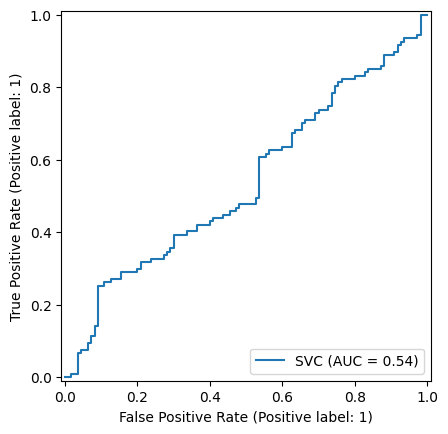

In [159]:
RocCurveDisplay.from_estimator(svc, x_test, y_test)

In [160]:
#arbol de decisión
dtc = DecisionTreeClassifier()
dtc = dtc.fit(x_train, y_train) 


In [161]:
dtc_pred = dtc.predict(x_test)
accuracy_score(y_test, dtc_pred)

0.5345622119815668

In [162]:
confusion_matrix(y_test, dtc_pred)

array([[54, 56],
       [45, 62]])

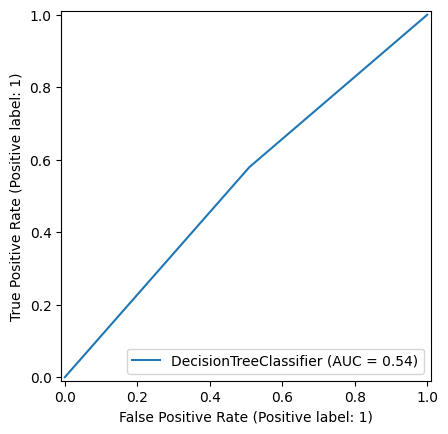

In [163]:
RocCurveDisplay.from_estimator(dtc, x_test, y_test)

In [164]:
#ramdom forest
rfc = RandomForestClassifier()
rfc = rfc.fit(x_train, y_train)

In [165]:
rfc_pred = rfc.predict(x_test)
accuracy_score(y_test, rfc_pred)

0.5529953917050692

In [166]:
confusion_matrix(y_test, rfc_pred)

array([[67, 43],
       [54, 53]])

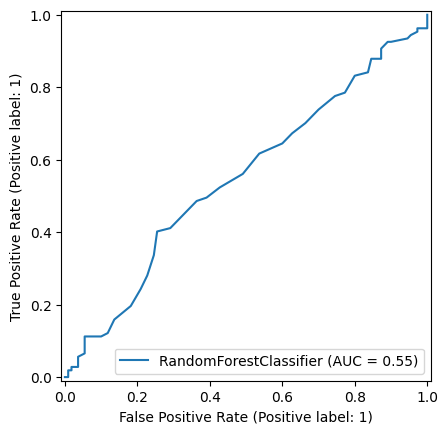

In [167]:
RocCurveDisplay.from_estimator(rfc, x_test, y_test)

In [168]:
#redes neuronales
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000)
mlp = mlp.fit(x_train, y_train)


In [169]:
mlp_pred = mlp.predict(x_test)
accuracy_score(y_test, mlp_pred)

0.48847926267281105

In [170]:
confusion_matrix(y_test, mlp_pred)

array([[55, 55],
       [56, 51]])

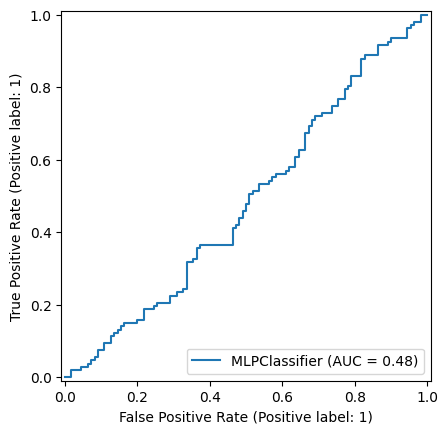

In [171]:
RocCurveDisplay.from_estimator(mlp, x_test, y_test)

In [183]:
#backtesting 
N = len(y_test) 
df = df.tail(N) 
df['Signals'] = rfc_pred 
df


Price,Close,High,Low,Open,Volume,EMA_5,EMA_20,EMA_50,EMA_100,RSI,ATR,Williams,Target,Signals,Equity
0,107802.328125,109298.289062,106812.929688,108992.171875,49155377493,1.006164,0.978827,0.922125,0.883479,61.350540,2896.980561,-39.583071,-1,1,100.000000
1,105641.757812,108910.046875,105374.398438,107795.570312,56022752042,1.017828,0.998956,0.943298,0.903498,54.679447,2942.599695,-64.199078,-1,-1,100.000000
2,103998.570312,106308.945312,103685.789062,105646.210938,57655287183,1.022606,1.013336,0.959842,0.919401,50.207935,2919.782306,-80.868518,1,-1,100.000000
3,104638.093750,104927.101562,103136.117188,103994.718750,38997843858,1.010904,1.006462,0.955780,0.915489,51.858027,2839.153882,-74.380824,1,1,100.000000
4,105652.101562,105884.546875,103826.953125,104637.296875,37397056873,1.000801,0.997107,0.948701,0.908550,54.436343,2783.328158,-64.094145,1,-1,100.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,87301.429688,89459.429688,86628.140625,87235.507812,42455674908,1.002423,1.014789,1.061263,1.126164,42.642249,2962.344386,-53.872190,1,1,139.078358
213,87802.156250,87874.781250,87182.976562,87301.429688,13741199310,0.997804,1.008144,1.053045,1.117371,44.616331,2800.162979,-44.509460,1,1,139.078358
214,87835.835938,87986.890625,87394.953125,87799.343750,15156557929,0.998281,1.007019,1.050577,1.114627,44.754060,2642.432587,-43.954204,-1,1,139.078358
215,87138.140625,90299.156250,86717.914062,87835.789062,48411625849,1.004183,1.013646,1.056676,1.121105,42.401671,2709.490416,-55.456666,1,1,137.687574


In [173]:
# backtesting

# resetear índice (CLAVE)
df = df.reset_index(drop=True)

# parámetros
equity = [100]

TP = 0.03
SL = 0.01

pos = 0
price = 0

N = len(df)

for i in range(1, N):

    equity.append(equity[i-1])

    # posición larga
    if pos == 1:

        if df['Close'].iloc[i] >= price * (1 + TP):
            pos = 0
            equity[i] *= (1 + TP)

        elif df['Close'].iloc[i] <= price * (1 - SL):
            pos = 0
            equity[i] *= (1 - SL)

    # posición corta
    elif pos == -1:

        if df['Close'].iloc[i] <= price * (1 - TP):
            pos = 0
            equity[i] *= (1 + TP)

        elif df['Close'].iloc[i] >= price * (1 + SL):
            pos = 0
            equity[i] *= (1 - SL)

    # si no hay posición
    else:

        if df['Signals'].iloc[i] != 0:
            pos = df['Signals'].iloc[i]
            price = df['Close'].iloc[i]

# guardar resultado
df['Equity'] = equity

<function matplotlib.pyplot.show(close=None, block=None)>

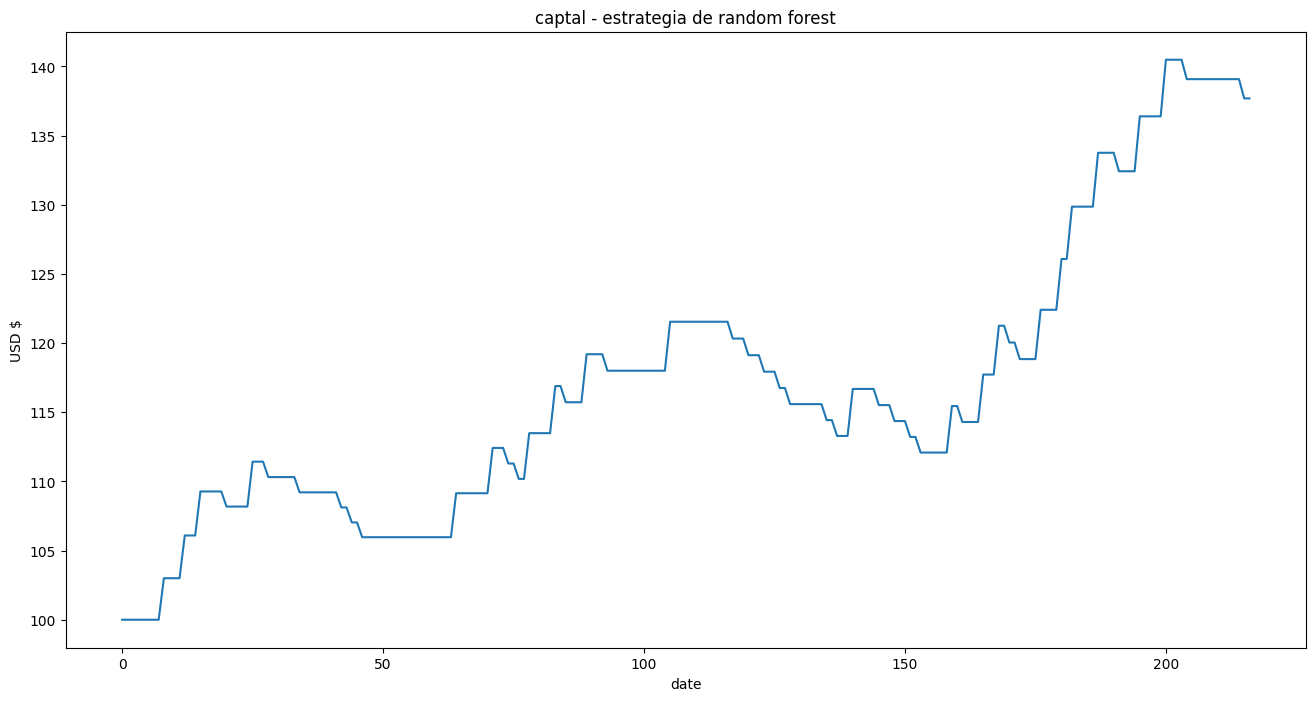

In [174]:
#mostrar visualmente el equity a lo largo de una ventana del tiempo 
from matplotlib import pyplot as plt
plt.figure(figsize=(16, 8))
plt.plot(df['Equity'])
plt.title('captal - estrategia de random forest')
plt.xlabel('date')
plt.ylabel('USD $')
plt.show

In [175]:
#desenpeño de la estrategia
ret = np.log(df['Equity']).diff().mean() 
ret *= 252

vol = np.log(df['Equity']).diff().std()
vol *= np.sqrt(252)

rf = 0.01

sharpe_ratio = (ret - rf) / vol
sharpe_ratio

np.float64(2.3879512519472237)

In [176]:
# descarag datos portafolio de mercado 
df2 = yfin.download("SPY", start="2025-05-28", end="2025-12-30")
df2

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2025-05-28,581.068848,586.051765,580.337244,584.855457,68445500
2025-05-29,583.362549,586.476872,579.427676,586.338444,69973300
2025-05-30,582.710083,584.430353,576.629761,582.255275,90601200
2025-06-02,585.992554,586.071604,578.429231,581.098642,61630500
2025-06-03,589.334106,590.312876,585.142111,585.626608,63606200
...,...,...,...,...,...
2025-12-22,682.964844,683.493369,678.736401,682.077253,69556700
2025-12-23,686.086304,686.325640,682.007416,682.057268,64840000


In [177]:
#estrategia long portafolio de mercado 
df2['Equity'] = (100/df2['Close'].iloc[0]) * df2['Close']
df2

Price,Close,High,Low,Open,Volume,Equity
Ticker,SPY,SPY,SPY,SPY,SPY,
Date,,,,,,
2025-05-28,581.068848,586.051765,580.337244,584.855457,68445500,100.000000
2025-05-29,583.362549,586.476872,579.427676,586.338444,69973300,100.394738
2025-05-30,582.710083,584.430353,576.629761,582.255275,90601200,100.282451
2025-06-02,585.992554,586.071604,578.429231,581.098642,61630500,100.847353
2025-06-03,589.334106,590.312876,585.142111,585.626608,63606200,101.422423
...,...,...,...,...,...,...
2025-12-22,682.964844,683.493369,678.736401,682.077253,69556700,117.535959
2025-12-23,686.086304,686.325640,682.007416,682.057268,64840000,118.073152


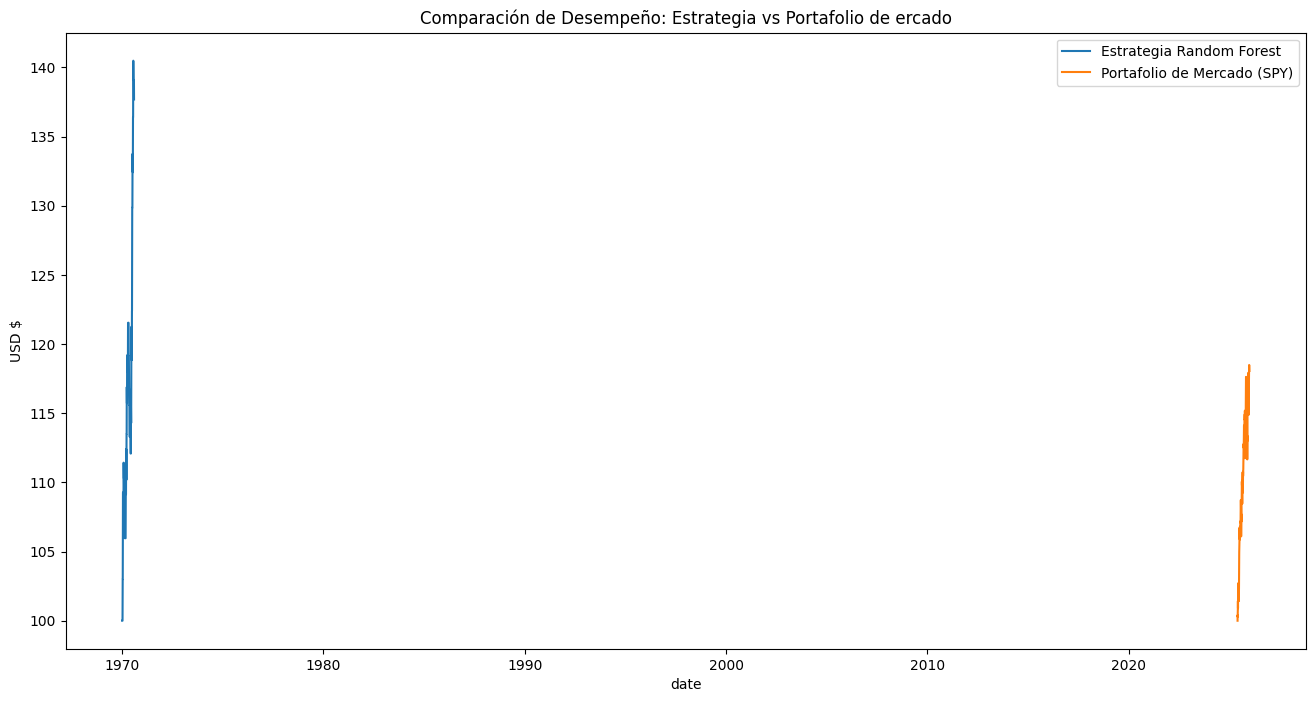

In [178]:
#comparar desempeño de la estrategia con el portafolio de mercado
plt.figure(figsize=(16, 8))
plt.plot(df['Equity'], label='Estrategia Random Forest')
plt.plot(df2['Equity'], label='Portafolio de Mercado (SPY)')
plt.title('Comparación de Desempeño: Estrategia vs Portafolio de ercado')
plt.xlabel('date')
plt.ylabel('USD $')
plt.legend(loc='upper right')
plt.show()

In [179]:
#desenpeño del portafolio de mercado
ret2 = np.log(df2['Equity']).diff().mean()
ret2 *= 252

vol = np.log(df2['Equity']).diff().std()
vol *= np.sqrt(252)

rf = 0.01

sharpe_ratio2 = (ret2 - rf) / vol
sharpe_ratio2


np.float64(2.555365182137168)